<a href="https://colab.research.google.com/github/Dona134/Metaphor-Classification-NLP/blob/main/Part2_stylistic_fingerprints.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Dona134/Metaphor-Classification-NLP/blob/main/main_code_upd%20(further%20work).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Colab + Imports + Paths

In [48]:
import pandas as pd, numpy as np, ast, json
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import torch, torch.nn as nn
from transformers import (
    XLMRobertaTokenizerFast, XLMRobertaForTokenClassification,
    Trainer, TrainingArguments
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings('ignore')
from transformers import logging; logging.set_verbosity_error()
import os; os.environ['TOKENIZER_PARALLELISM'] = 'false'

# === NO DRIVE MOUNT — Load directly from GitHub ===
VUAMC_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/vuamc_token.jsonl"
RU_URL    = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/ru_large_token.jsonl"

def load_jsonl_from_url(url):
    import urllib.request
    rows = []
    with urllib.request.urlopen(url) as f:
        for line in f:
            rows.append(json.loads(line.decode('utf-8').strip()))
    return pd.DataFrame(rows)

print("Loading VUAMC...")
df_vuamc = load_jsonl_from_url(VUAMC_URL)
print(f"VUAMC: {len(df_vuamc)} rows")



# Models save locally in Colab session
MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)


Loading VUAMC...
VUAMC: 16740 rows


In [49]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForTokenClassification, Trainer, TrainingArguments, pipeline
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

## Config

In [50]:
EXPERIMENT = "EN"  # "EN", "RU_ZERO", "RU_HEAD", "RU_FULL", "EN_BALANCED_POS"
MAX_LEN = 32
BATCH_SIZE = 16
SEED = 42
# # Final weights from your runs
# EN_CLASS_WEIGHTS = torch.tensor([0.56, 4.69])
# #EN_CLASS_WEIGHTS = torch.tensor([0.58, 3.54])
# RU_CLASS_WEIGHTS = torch.tensor([0.53, 8.89])  # 95/5 RU imbalance
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

## Load VUAMC EN

In [51]:
import urllib.request

VUAMC_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/vuamc_token.jsonl"

print("Loading VUAMC from GitHub...")
df_list = []
with urllib.request.urlopen(VUAMC_URL) as f:
    for line in f:
        rec = json.loads(line.decode('utf-8').strip())
        df_list.append(rec)

df_vuamc = pd.DataFrame(df_list)
print(f"Loaded {len(df_vuamc)} preprocessed sentences")
print("Shape:", df_vuamc.shape)
print("\nSample:")
df_vuamc.head()


Loading VUAMC from GitHub...
Loaded 16740 preprocessed sentences
Shape: (16740, 5)

Sample:


,document_name,words,token_labels,sentence_label,pos
0,a1e-fragment01,"[Latest, corporate, unbundler, reveals, laid-b...","[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",1,"[adj, adj, noun, verb, adj, noun, nan, noun, n..."
1,a1e-fragment01,"[By, FRANK, KANE]","[0, 0, 0]",0,"[nan, noun, noun]"
2,a1e-fragment01,"[IT, SEEMS, that, Roland, Franklin, ,, the, la...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,"[nan, verb, nan, noun, noun, nan, nan, adj, no..."
3,a1e-fragment01,"[He, has, not, properly, investigated, the, ta...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]",1,"[nan, verb, nan, adv, verb, nan, noun, nan, no..."
4,a1e-fragment01,"[The, 63-year-old, head, of, Pembridge, Invest...","[0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",1,"[nan, adj, noun, nan, noun, noun, nan, nan, na..."


In [52]:
# average #sentences per document
print(df_vuamc['document_name'].value_counts().mean())
# average #words
print(df_vuamc['words'].apply(len).mean())

143.07692307692307
14.521863799283155


In [53]:
# document wise splitting to avoid leakage
def make_doc_splits(df, test_size=0.5, val_size=0.5, seed=42):
    doc_ids = df["document_name"].unique()
    train_ids, temp_ids = train_test_split(doc_ids, test_size=test_size, random_state=seed)
    val_ids, test_ids = train_test_split(temp_ids, test_size=val_size, random_state=seed)
    return (df[df["document_name"].isin(train_ids)].reset_index(drop=True),
            df[df["document_name"].isin(val_ids)].reset_index(drop=True),
            df[df["document_name"].isin(test_ids)].reset_index(drop=True))

In [54]:
# sample 8000
df_vuamc = df_vuamc.sample(10000, random_state=42)

In [55]:
# creating train_df, val_df and test_df, seed
train_df, val_df, test_df = make_doc_splits(df_vuamc, test_size=0.5, val_size=0.5, seed=42)

In [56]:
train_df.head()

,document_name,words,token_labels,sentence_label,pos
0,a4d-fragment02,"[In, the, case, of, Bankside, Power, Station, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",1,"[nan, nan, noun, nan, noun, noun, noun, nan, n..."
1,b1g-fragment02,"[Though, there, has, been, a, change, of, Prim...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,"[nan, nan, verb, verb, nan, noun, nan, adj, no..."
2,a1g-fragment26,"[The, East, German, government, 's, decision, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,"[nan, noun, adj, noun, nan, noun, nan, verb, n..."
3,a3m-fragment02,"[In, Milan, ,, for example, ,, the, commission...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",1,"[nan, noun, nan, adv, nan, nan, noun, nan, ver..."
4,kcu-fragment02,"[It, is, ]","[0, 0, 0]",0,"[nan, verb, noun]"


In [57]:
# shape of all three dfs
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(4785, 5)
(2479, 5)
(2736, 5)


In [58]:
# unique documents in test_df
test_df['document_name'].nunique()


30

## Pipeline

### Train SENTENCE Classifier

In [59]:
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

class SentDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.sents = [' '.join(r['words']) for _,r in df.iterrows()]
        self.labels = df['sentence_label'].values
        self.tok = tokenizer

    def __len__(self): return len(self.sents)
    def __getitem__(self, idx):
        enc = self.tok(self.sents[idx], truncation=True, padding='max_length', max_length=32, return_tensors='pt')
        return {'input_ids': enc['input_ids'].flatten(), 'attention_mask': enc['attention_mask'].flatten(), 'labels': torch.tensor(self.labels[idx])}


train_ds = SentDataset(train_df, tokenizer)
val_ds = SentDataset(val_df, tokenizer)

sent_model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

args = TrainingArguments(
    output_dir='./sent_model', per_device_train_batch_size=16, num_train_epochs=3,
    eval_strategy='epoch', save_strategy='no', fp16=False, report_to=[] # Changed fp16 to False
)

sent_trainer = Trainer(model=sent_model, args=args, train_dataset=train_ds, eval_dataset=val_ds)
sent_trainer.train()
sent_trainer.save_model('./sent_model')

# Test
sent_pipe = pipeline('text-classification', model='./sent_model', tokenizer=tokenizer)
print("Sentence test:", sent_pipe("The lion roared like thunder.")[0])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'eval_loss': '0.3823', 'eval_runtime': '7.965', 'eval_samples_per_second': '311.3', 'eval_steps_per_second': '38.92', 'epoch': '1'}
{'loss': '0.4311', 'grad_norm': '10.95', 'learning_rate': '2.228e-05', 'epoch': '1.667'}
{'eval_loss': '0.4127', 'eval_runtime': '7.384', 'eval_samples_per_second': '335.7', 'eval_steps_per_second': '41.98', 'epoch': '2'}
{'eval_loss': '0.5024', 'eval_runtime': '7.527', 'eval_samples_per_second': '329.3', 'eval_steps_per_second': '41.18', 'epoch': '3'}
{'train_runtime': '154.3', 'train_samples_per_second': '93.06', 'train_steps_per_second': '5.835', 'train_loss': '0.3448', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence test: {'label': 'LABEL_0', 'score': 0.7604180574417114}


In [60]:
# the number of met sentences in test_df
test_df['sentence_label'].value_counts()

,count
sentence_label,
1,1371
0,1365


In [61]:
# Calculate the absolute number of metaphorical tokens in test_df
total_metaphorical_tokens = test_df['token_labels'].apply(lambda x: sum(x)).sum()

print(f"Absolute number of metaphorical tokens in test_df: {int(total_metaphorical_tokens)}")

Absolute number of metaphorical tokens in test_df: 4504


In [62]:
test_df.shape

(2736, 5)

              precision    recall  f1-score   support

     LITERAL      0.808     0.875     0.840      1365
    METAPHOR      0.864     0.793     0.827      1371

    accuracy                          0.834      2736
   macro avg      0.836     0.834     0.833      2736
weighted avg      0.836     0.834     0.833      2736



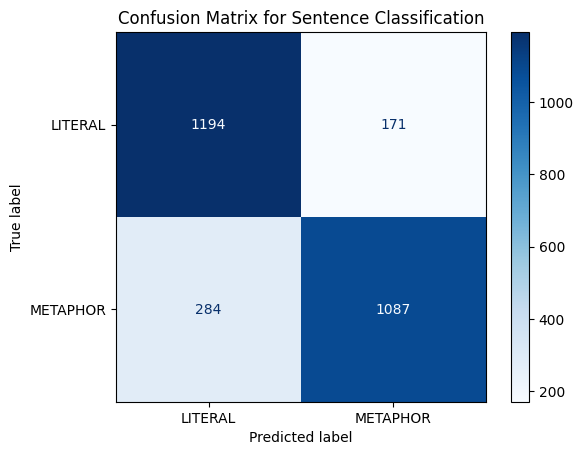

In [63]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Build a dataset for test_df
test_ds = SentDataset(test_df, tokenizer)

# Use Trainer to predict
pred_output = sent_trainer.predict(test_ds)
logits = pred_output.predictions
y_pred = logits.argmax(axis=1)
y_true = np.array(test_df['sentence_label'])

print(classification_report(
    y_true, y_pred,
    target_names=["LITERAL", "METAPHOR"],
    digits=3
))

# Add a confusion matrix for better error analysis
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["LITERAL", "METAPHOR"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Sentence Classification")
plt.show()

# Train TOKEN classifier

In [64]:
import torch.nn as nn

class TokenDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len=32):
        self.words = [r['words'] for _,r in df.iterrows()]
        self.labels = [r['token_labels'] for _,r in df.iterrows()]
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.words)


    def __getitem__(self, idx):
        words = self.words[idx]
        labels = self.labels[idx]
    # Pad labels to max_len
        padded_labels = labels + [-100] * (self.max_len - len(labels))
        padded_labels = padded_labels[:self.max_len]  # Truncate if still too long


        # Tokenize with fixed padding
        encoding = self.tok(
            words,
            is_split_into_words=True,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Align labels to tokens (ignore subwords)
        word_ids = encoding.word_ids()
        aligned_labels = [-100] * self.max_len
        for i, wid in enumerate(word_ids):
            if wid is not None and wid < len(labels):
                aligned_labels[i] = labels[wid]

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(aligned_labels, dtype=torch.long)
        }

# Initialize roberta-base tokenizer (matching the model)
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

# Now it works
token_train = TokenDataset(train_df, tokenizer)
token_val = TokenDataset(val_df, tokenizer)

# Change the base model from 'xlm-roberta-base' to 'roberta-base'
token_model = AutoModelForTokenClassification.from_pretrained('roberta-base', num_labels=2)

# --- New: Compute and apply class weights ---
# First, collect all token labels from the training set to compute balanced weights
all_train_token_labels = []
for labels_list in train_df['token_labels']:
    all_train_token_labels.extend([label for label in labels_list if label != -100]) # Exclude padding

# Calculate the actual class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_train_token_labels),
    y=all_train_token_labels
)
computed_class_weights = torch.tensor(class_weights_array, dtype=torch.float)
print(f"Computed Class Weights (LITERAL, METAPHOR): {computed_class_weights.tolist()}")

# --- Manual adjustment of metaphor weight (for experimentation) ---
# Reduce the metaphor weight to improve precision
# You can change this multiplier to fine-tune the balance
METAPHOR_WEIGHT_REDUCTION_FACTOR = 0.3 # Try 1.0 (no change), 0.8, 0.5, etc.
computed_class_weights[1] = computed_class_weights[1] * METAPHOR_WEIGHT_REDUCTION_FACTOR
print(f"Adjusted Class Weights (LITERAL, METAPHOR): {computed_class_weights.tolist()}")

# Custom Trainer to inject class weights into the loss function
class CustomTokenTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None): # Added num_items_in_batch
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Initialize CrossEntropyLoss with computed class weights
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device) if self.class_weights is not None else None)

        # Only consider active parts of the loss (labels not -100)
        active_loss = labels.view(-1) != -100
        active_logits = logits.view(-1, self.model.config.num_labels)[active_loss]
        active_labels = labels.view(-1)[active_loss]

        loss = loss_fct(active_logits, active_labels)
        return (loss, outputs) if return_outputs else loss

# --- End New ---

token_args = TrainingArguments(
    output_dir='./token_model',
    per_device_train_batch_size=16,
    num_train_epochs=3,
    eval_strategy='epoch',
    save_strategy='no',
    fp16=False, # Changed to False
    report_to=[],
    dataloader_pin_memory=False  # Extra safety
)

import gc
import torch
gc.collect()
torch.cuda.empty_cache()

token_trainer = CustomTokenTrainer(model=token_model, args=token_args, train_dataset=token_train, eval_dataset=token_val, class_weights=computed_class_weights)
token_trainer.train()
token_trainer.save_model('./token_model')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Computed Class Weights (LITERAL, METAPHOR): [0.5535666942596436, 5.167080402374268]
Adjusted Class Weights (LITERAL, METAPHOR): [0.5535666942596436, 1.550124168395996]
{'eval_loss': '0.276', 'eval_runtime': '5.56', 'eval_samples_per_second': '445.8', 'eval_steps_per_second': '55.75', 'epoch': '1'}
{'loss': '0.3061', 'grad_norm': '7.914', 'learning_rate': '2.228e-05', 'epoch': '1.667'}
{'eval_loss': '0.2818', 'eval_runtime': '5.479', 'eval_samples_per_second': '452.4', 'eval_steps_per_second': '56.58', 'epoch': '2'}
{'eval_loss': '0.3254', 'eval_runtime': '5.386', 'eval_samples_per_second': '460.3', 'eval_steps_per_second': '57.56', 'epoch': '3'}
{'train_runtime': '124.4', 'train_samples_per_second': '115.4', 'train_steps_per_second': '7.235', 'train_loss': '0.2493', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Extracting False Positives and False Negatives for Token Classification

In [66]:
from transformers import pipeline
import numpy as np
import torch

# Re-create the token pipeline if not already done in the session
token_pipe = pipeline(
    'token-classification',
    model='./token_model',
    tokenizer=tokenizer
    # aggregation_strategy='simple' # Temporarily remove for raw token output
)

# Prepare lists to store misclassified examples
false_positives = [] # Actual: LITERAL, Predicted: METAPHOR
false_negatives = [] # Actual: METAPHOR, Predicted: LITERAL

print("Analyzing token errors in test_df (raw tokens)...")

for idx, row in test_df.iterrows():
    words = row['words']
    true_token_labels = row['token_labels']
    sentence = ' '.join(words)

    if not sentence.strip(): # Skip empty sentences
        continue

    # Get raw predictions from the token pipeline
    raw_predictions = token_pipe(sentence)

    # Re-tokenize the sentence to get alignment for true labels
    tokenized_input = tokenizer(words, is_split_into_words=True, truncation=True, max_length=MAX_LEN, return_tensors='pt')

    # Align predictions to original words using word_ids
    word_ids = tokenized_input.word_ids()

    # Create a list to hold aligned predicted labels for original words
    aligned_predicted_labels = [-1] * len(words) # -1 indicates no prediction or unassigned

    # Map raw predictions to original words.
    # We'll take the prediction of the first subword token for each word.
    current_word_idx = None
    for pred in raw_predictions:
        # Find the word_id corresponding to this prediction's span
        # This is tricky because `raw_predictions` might not directly give word_ids
        # Let's try to map character spans back to words
        token_start = pred['start']
        token_end = pred['end']

        # Find which original word this predicted token corresponds to
        # This requires iterating through the original words and their character spans
        char_idx = 0
        word_matched_idx = -1
        for w_idx, w in enumerate(words):
            word_char_start = char_idx
            word_char_end = char_idx + len(w)

            # If the predicted token's span overlaps with the word's span, assign it
            # Simple overlap check: if token starts within word or word starts within token
            if (token_start >= word_char_start and token_start < word_char_end) or \
               (word_char_start >= token_start and word_char_start < token_end):
                word_matched_idx = w_idx
                break
            char_idx += len(w) + 1 # +1 for space

        if word_matched_idx != -1 and word_matched_idx < len(aligned_predicted_labels):
            predicted_label = 1 if pred['entity'] == 'LABEL_1' else 0
            # Assign the predicted label to the word. If multiple subwords for one word,
            # the last one (or first one found) will set the label. A more robust way
            # would be to average or vote, but for FP/FN identification, this is a start.
            aligned_predicted_labels[word_matched_idx] = predicted_label

    # Now compare aligned_predicted_labels with true_token_labels
    for w_idx, (true_label, predicted_label) in enumerate(zip(true_token_labels, aligned_predicted_labels)):
        if predicted_label == -1: # Skip words that weren't covered by predictions for some reason
            continue

        original_word = words[w_idx]

        # False Positive: Actual LITERAL (0), Predicted METAPHOR (1)
        if true_label == 0 and predicted_label == 1:
            false_positives.append({
                'sentence': sentence,
                'token': original_word,
                'true_label': true_label,
                'predicted_label': predicted_label,
                'original_word_context': original_word # Now it's the exact word
            })
        # False Negative: Actual METAPHOR (1), Predicted LITERAL (0)
        elif true_label == 1 and predicted_label == 0:
            false_negatives.append({
                'sentence': sentence,
                'token': original_word,
                'true_label': true_label,
                'predicted_label': predicted_label,
                'original_word_context': original_word # Now it's the exact word
            })

print(f"Found {len(false_positives)} false positives.")
print(f"Found {len(false_negatives)} false negatives.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Analyzing token errors in test_df (raw tokens)...
Found 688 false positives.
Found 2212 false negatives.


#### Sample False Positives

In [67]:
import random

if false_positives:
    print("--- 10 Sample False Positives (Literal predicted as Metaphor) ---")
    for i, fp_example in enumerate(random.sample(false_positives, min(10, len(false_positives)))):
        print(f"\nExample {i+1}:")
        print(f"  Sentence: {fp_example['sentence']}")
        print(f"  Misclassified Token: '{fp_example['token']}' (Original word in context: '{fp_example['original_word_context']}')")
        print(f"  True Label: LITERAL, Predicted Label: METAPHOR")
else:
    print("No false positives found (or list is empty).")


--- 10 Sample False Positives (Literal predicted as Metaphor) ---

Example 1:
  Sentence: We must show that it is possible for it to be both a resultant … and a totalizing force … how it can continually bring about the unity of dispersive profusion and integration .
  Misclassified Token: 'totalizing' (Original word in context: 'totalizing')
  True Label: LITERAL, Predicted Label: METAPHOR

Example 2:
  Sentence: Buzz never cheated to let Elinor win : she knew that Elinor would immediately sense this and feel humiliated .
  Misclassified Token: 'sense' (Original word in context: 'sense')
  True Label: LITERAL, Predicted Label: METAPHOR

Example 3:
  Sentence: He feels that Keyser 's problems were hastened by an unwise acquisition .
  Misclassified Token: 'hastened' (Original word in context: 'hastened')
  True Label: LITERAL, Predicted Label: METAPHOR

Example 4:
  Sentence: If you like hanging out washing rather than drying it in the bowels of an expensive machine , you will need to t

#### Sample False Negatives

In [68]:
import random

if false_negatives:
    print("--- 10 Sample False Negatives (Metaphor predicted as Literal) ---")
    for i, fn_example in enumerate(random.sample(false_negatives, min(10, len(false_negatives)))):
        print(f"\nExample {i+1}:")
        print(f"  Sentence: {fn_example['sentence']}")
        print(f"  Misclassified Token: '{fn_example['token']}' (Original word in context: '{fn_example['original_word_context']}')")
        print(f"  True Label: METAPHOR, Predicted Label: LITERAL")
else:
    print("No false negatives found (or list is empty).")


--- 10 Sample False Negatives (Metaphor predicted as Literal) ---

Example 1:
  Sentence: Well , one can use eqn ( 3.1 ) as it is , but very often one is better off by using its integral form that can be obtained by integrating both sides of eqn ( 3.1 ) over a surface [formula] .
  Misclassified Token: 'integrating' (Original word in context: 'integrating')
  True Label: METAPHOR, Predicted Label: LITERAL

Example 2:
  Sentence: It could be copied only either by those of nearly equal wealth or by those who could concentrate their resources chiefly on defence — princes , great bishops or , in the south especially , towns .
  Misclassified Token: 'in' (Original word in context: 'in')
  True Label: METAPHOR, Predicted Label: LITERAL

Example 3:
  Sentence: We 'll have the Wednesday off when you cross   
  Misclassified Token: 'cross' (Original word in context: 'cross')
  True Label: METAPHOR, Predicted Label: LITERAL

Example 4:
  Sentence: The usual tactic was to march troops across the 

## Application

In [71]:
GITHUB_DATA_BASE_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/"

# --- USER INPUT: Change this to the CSV filename you want to load ---
csv_filename = 'NarraDetect.csv' # Example: 'NarraDetect.csv', 'another_file.csv'
# -------------------------------------------------------------------

csv_url = f"{GITHUB_DATA_BASE_URL}{csv_filename}"

print(f"Loading {csv_filename} from GitHub...")
try:
    df_new_test = pd.read_csv(csv_url)
    print(f"Successfully loaded {len(df_new_test)} rows from {csv_filename}")
except Exception as e:
    print(f"Error loading {csv_filename}: {e}")
    print("Please ensure the filename is correct and the file exists in the specified GitHub path.")
    # Optionally, you might want to exit or use a fallback DataFrame here
    # For now, we'll proceed assuming df_new_test might be empty or problematic
    df_new_test = pd.DataFrame() # Create an empty DataFrame to avoid crashes if loading fails


# Assign the loaded dataframe to test_df
test_df = df_new_test

# Apply the necessary preprocessing steps for the test_df
if not test_df.empty:
    # Sample 20% of the dataset
    sample_fraction = 0.15
    if len(test_df) > 0:
        num_samples = max(1, int(len(test_df) * sample_fraction)) # Ensure at least 1 sample if data exists
        test_df = test_df.sample(n=num_samples, random_state=42).reset_index(drop=True)
        print(f"Sampled {sample_fraction*100}% of the dataset, resulting in {len(test_df)} rows.")
    else:
        print("DataFrame is empty, no sampling performed.")

    # Convert the 'words' column from string to actual list
    # Ensure the 'words' column exists before trying to convert
    if 'words' in test_df.columns:
        try:
            test_df['words'] = test_df['words'].apply(ast.literal_eval)
        except ValueError as e:
            print(f"Warning: Could not convert 'words' column to list. Error: {e}")
            print("Assuming 'words' column is already in list format or will be handled downstream.")
            # If conversion fails, ensure it's still treated as a list of strings if possible
            test_df['words'] = test_df['words'].apply(lambda x: x if isinstance(x, list) else [str(x)])
    else:
        print("Warning: 'words' column not found in the loaded DataFrame. This may cause issues with subsequent steps.")
        # Add a dummy 'words' column to prevent crashes if it's truly missing
        test_df['words'] = test_df.apply(lambda row: ['dummy'] * (MAX_LEN // 2), axis=1)

    # Add placeholder columns for unlabeled data if they don't exist
    if 'sentence_label' not in test_df.columns:
        test_df['sentence_label'] = 0
    if 'token_labels' not in test_df.columns:
        test_df['token_labels'] = test_df['words'].apply(lambda x: [0] * len(x))

    print("Processed test_df head:")
    display(test_df.head())
    print(f"Processed test_df shape: {test_df.shape}")
else:
    print("test_df is empty or could not be loaded.")

Loading NarraDetect.csv from GitHub...
Successfully loaded 19278 rows from NarraDetect.csv
Sampled 20.0% of the dataset, resulting in 3855 rows.
Processed test_df head:


,document_name,id,words,sentence_label,token_labels
0,SHORT,xc59kapxbsce,"[He, could, recall, his, father, s, face, clea...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,REDDIT,l7imf5nc6akd,"[We, go, through, the, city, and, complete, th...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,LITSTUDY,yeuqq5iw0zj9,"[And, the, leaves, being, connected, by, milli...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,APHORISM,jayghhrgu580,"[Every, kind, of, life, the, most, unfavourabl...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,HIST,mhhlar80fdne,"[North, s, first, challenge, was, to, secure, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


Processed test_df shape: (3855, 5)


# Building the pipeline

In [72]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Running the experiment

In [74]:
from transformers import pipeline

sent_pipe = pipeline(
    'text-classification',
    model='./sent_model',
    tokenizer=tokenizer,
    return_all_scores=True,
    device="cpu", # Use GPU if available
    max_length=MAX_LEN, # Explicitly set max_length
    truncation=True    # Ensure truncation is applied
)
token_pipe = pipeline(
    'token-classification',
    model='./token_model',
    tokenizer=tokenizer,
    aggregation_strategy='simple',
    device="cpu" # Use GPU if available
    # max_length=MAX_LEN, # Removed: not a valid argument for TokenClassificationPipeline init
    # truncation=True    # Removed: not a valid argument for TokenClassificationPipeline init
)

# The following lines are commented out as they were for a sanity check
# with ground truth labels, which are not present in the current test_df.
# row = test_df[test_df['sentence_label'] == 1].iloc[0]
# sent = ' '.join(row['words'])
# gt_tokens = [row['words'][i] for i, l in enumerate(row['token_labels']) if l == 1]

# print("Sentence :", sent[:80])
# print("GT metaphor tokens :", gt_tokens)
# print("Sent pipe :", sent_pipe(sent))
# print("Token pipe :", [(e['word'], e['entity_group'], round(e['score'],3))
#                        for e in token_pipe(sent)])


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [75]:
def pipeline_on_test_df(df, sent_pipe, token_pipe, threshold=0.5, batch_size=32):
    doc_results = {}

    # Prepare all sentences for batch processing
    all_sentences = [' '.join(r['words']) for _, r in df.iterrows()]
    sentence_map = [] # To map results back to original df structure
    for i, (_, row) in enumerate(df.iterrows()):
        sentence_map.append({'doc_name': row['document_name'], 'sentence_idx': i})

    # Batch Sentence Classification
    print(f"Processing {len(all_sentences)} sentences with sentence pipeline in batches...")
    sent_preds_batch = sent_pipe(all_sentences, batch_size=batch_size)

    metaphorical_sentences = []
    metaphorical_sentence_indices = []

    # sent_preds_batch is a list of lists of dictionaries when return_all_scores=True
    # Each inner list (sent_scores_for_one_sentence) contains all label scores for a single sentence.
    # However, for batch processing, it often returns a flat list of top predictions if not explicitly handled.
    for i, sent_pred_item in enumerate(sent_preds_batch):
        # Check if sent_pred_item is a list (meaning all scores were returned for one sentence)
        if isinstance(sent_pred_item, list):
            # Find the score for 'LABEL_1' (metaphor)
            meta_prob = next((s['score'] for s in sent_pred_item if s['label'] == 'LABEL_1'), 0.0)
        else:
            # sent_pred_item is a single dictionary (top prediction)
            meta_prob = sent_pred_item['score'] if sent_pred_item['label'] == 'LABEL_1' else 0.0

        if meta_prob > threshold:
            metaphorical_sentences.append(all_sentences[i])
            metaphorical_sentence_indices.append(i)

    # Batch Token Classification for metaphorical sentences only
    if metaphorical_sentences:
        print(f"Processing {len(metaphorical_sentences)} metaphorical sentences with token pipeline in batches...")
        token_preds_batch = token_pipe(metaphorical_sentences, batch_size=batch_size)
    else:
        token_preds_batch = []

    # Map results back to documents
    doc_meta_tokens_raw = {doc_name: [] for doc_name in df['document_name'].unique()}
    token_pred_idx = 0
    for i, original_sent_idx in enumerate(metaphorical_sentence_indices):
        doc_name = sentence_map[original_sent_idx]['doc_name']
        if token_pred_idx < len(token_preds_batch):
            entities = token_preds_batch[token_pred_idx]
            meta_words = [
                e['word'].replace('▁', '').strip()
                for e in entities if e['entity_group'] == 'LABEL_1'
            ]
            doc_meta_tokens_raw[doc_name].extend(meta_words)
            token_pred_idx += 1

    # Aggregate unique metaphors per document
    for doc_name, tokens in doc_meta_tokens_raw.items():
        doc_results[doc_name] = list(set(w for w in tokens if w))

    return doc_results

In [76]:
test_results = pipeline_on_test_df(test_df, sent_pipe, token_pipe, threshold=0.5)

print(f"Docs processed: {len(test_results)}")
print(f"Docs with \u22651 metaphor: {sum(1 for m in test_results.values() if m)}")
print(f"Avg metaphors/doc: {np.mean([len(m) for m in test_results.values()]):.1f}")
print("\nFirst 5 docs:")
for doc, metas in list(test_results.items())[:5]:
    print(f"  {doc}: {metas[:8]}")

Processing 3855 sentences with sentence pipeline in batches...
Processing 2663 metaphorical sentences with token pipeline in batches...
Docs processed: 18
Docs with ≥1 metaphor: 18
Avg metaphors/doc: 255.9

First 5 docs:
  SHORT: ['buffeting', 'these things', 'spooked', 'betrayal', 'these', 'With', 'raft', 'long']
  REDDIT: ['take flight', 'into paroxys', 'point', 'stopped', 'wrecking', 'these', 'met', 'With']
  LITSTUDY: ['space', 'conventions', 'mean', 'impart', 'rat', 'associates', 'toward', 'impact']
  APHORISM: ['That energy with', 'bears', 'mean', 'prepared', 'inc', 'arranges themes', 'with resistance with', 'respecting']
  HIST: ['possession', 'started with', 'initiative', 'mean', 'relieved', 'brutal', 'lines', 'category']


In [77]:
percentage_metaphorical_tokens = {}
for doc_name, metaphor_tokens in test_results.items():
    # Get all words for the current document from the original test_df
    doc_words = test_df[test_df['document_name'] == doc_name]['words'].explode().tolist()
    total_words_in_doc = len(doc_words)

    num_metaphorical_tokens = len(metaphor_tokens)

    if total_words_in_doc > 0:
        percentage = (num_metaphorical_tokens / total_words_in_doc) * 100
        percentage_metaphorical_tokens[doc_name] = percentage
    else:
        percentage_metaphorical_tokens[doc_name] = 0.0 # Handle empty documents

# Calculate the average percentage across all documents
if percentage_metaphorical_tokens:
    average_percentage = np.mean(list(percentage_metaphorical_tokens.values()))
    print(f"Average percentage of metaphorical tokens per document: {average_percentage:.2f}%")
else:
    print("No documents found or no metaphorical tokens identified.")

Average percentage of metaphorical tokens per document: 5.06%


In [78]:
import pandas as pd

# Convert the dictionary to a DataFrame for better display
df_genre_percentages = pd.DataFrame(
    list(percentage_metaphorical_tokens.items()),
    columns=['Genre', 'Metaphorical Token Percentage (%)']
)

# Sort by percentage for easier analysis (optional)
df_genre_percentages = df_genre_percentages.sort_values(
    by='Metaphorical Token Percentage (%)',
    ascending=False
).reset_index(drop=True)

print("Average percentage of metaphorical tokens per document by genre:")
display(df_genre_percentages)

Average percentage of metaphorical tokens per document by genre:


,Genre,Metaphorical Token Percentage (%)
0,APHORISM,11.545712
1,BREVIEW,8.209250
2,LITSTUDY,8.113354
3,PHIL,6.897130
4,NOVEL19C,5.953905
5,BIO,5.775646
6,SCOTUS,5.302227
7,HIST,5.295389
8,FLASH,4.963899
9,MEM,4.790583


# Adding features & creating fingerprints

In [79]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import numpy as np
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

english_stopwords = set(stopwords.words('english'))

def calculate_document_stylistic_features(doc_df, pipeline_meta_tokens):
    doc_features = {}

    # 1. Metaphor Density (from pipeline output)
    total_words_in_doc = doc_df['words'].apply(len).sum()
    num_pipe_metaphors = len(pipeline_meta_tokens)
    doc_features['pipeline_metaphor_density'] = num_pipe_metaphors / (total_words_in_doc + 1e-6)

    # 2. Average Sentence Length
    sentence_lengths = doc_df['words'].apply(len)
    doc_features['avg_sentence_length'] = sentence_lengths.mean()

    # 3. Sentence Length Variance
    doc_features['sentence_length_variance'] = sentence_lengths.var()

    # 4. Function Word Frequencies
    all_words_in_doc = [word.lower() for words_list in doc_df['words'] for word in words_list]
    function_words_count = sum(1 for w in all_words_in_doc if w in english_stopwords)
    doc_features['function_word_ratio'] = function_words_count / (len(all_words_in_doc) + 1e-6)

    # 5. POS Tag Ratios (e.g., Adjective-Noun Ratio)
    # all_pos_tags = [tag for pos_list in doc_df['pos'] for tag in pos_list if pd.notna(tag)]
    # pos_counts = Counter(all_pos_tags)
    # num_adj = pos_counts.get('adj', 0)
    # num_noun = pos_counts.get('noun', 0)
    # doc_features['pos_adj_noun_ratio'] = num_adj / (num_noun + 1e-6)

    # 6. Unique Vocabulary Ratio
    unique_words = set(w.lower() for words_list in doc_df['words'] for w in words_list)
    doc_features['unique_vocabulary_ratio'] = len(unique_words) / (len(all_words_in_doc) + 1e-6)

    return doc_features

print("Calculating document-level stylistic features...")

all_doc_stylistic_features = []
for doc_name, doc_group in test_df.groupby('document_name'):
    pipeline_metas = test_results.get(doc_name, []) # Metaphor tokens detected by pipeline for this doc
    features = calculate_document_stylistic_features(doc_group, pipeline_metas)
    features['document_name'] = doc_name
    all_doc_stylistic_features.append(features)

df_document_stylistics = pd.DataFrame(all_doc_stylistic_features)

print("Stylistic features computed for each document:")
display(df_document_stylistics.head())
print(f"Shape of document stylistics DataFrame: {df_document_stylistics.shape}")

Calculating document-level stylistic features...
Stylistic features computed for each document:


,pipeline_metaphor_density,avg_sentence_length,sentence_length_variance,function_word_ratio,unique_vocabulary_ratio,document_name
0,0.007959,21.724299,98.463538,0.368466,0.430200,ABSTRACT
1,0.115457,29.609302,299.893371,0.511781,0.322809,APHORISM
2,0.057756,21.800000,269.978082,0.478524,0.397832,BIO
3,0.082093,36.138095,494.626771,0.444854,0.364080,BREVIEW
4,0.040272,27.119816,299.244837,0.547154,0.274766,FABLE


Shape of document stylistics DataFrame: (18, 6)


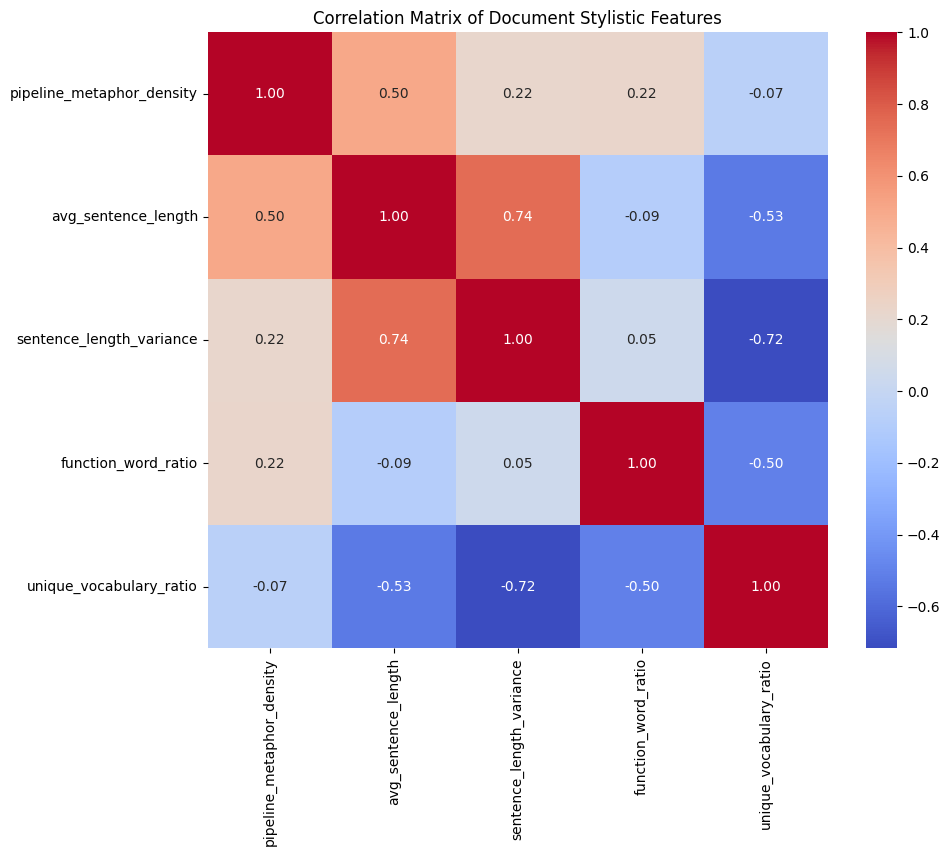

In [80]:
# plot correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_document_stylistics.drop(columns=['document_name']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Document Stylistic Features')
plt.show()

# Clustering

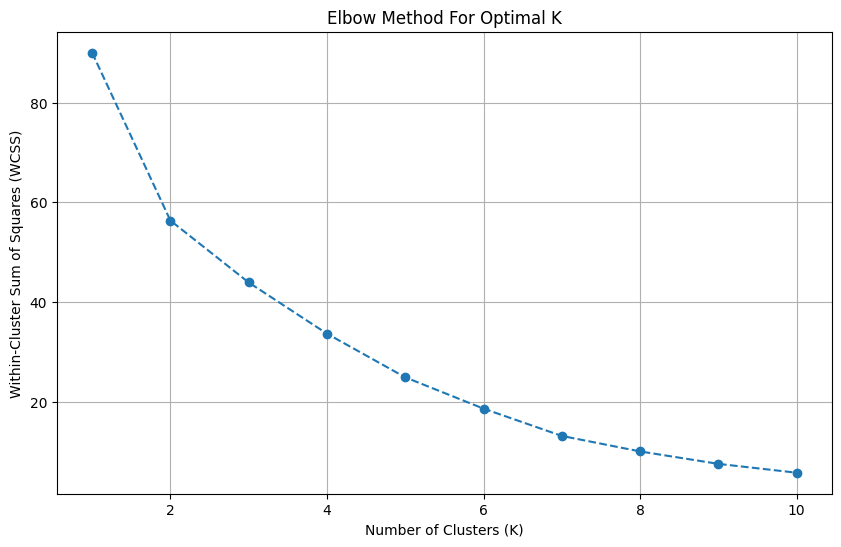

Please examine the plot above and choose an optimal 'k' value where the decrease in WCSS starts to slow down. I will proceed with k=3 as an example, but you can adjust this based on the elbow plot.


In [81]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for clustering
features_to_cluster = df_document_stylistics.drop(columns=['document_name'])

# Standardize the features - important for distance-based clustering algorithms like K-Means
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_cluster)

# Determine optimal number of clusters using the elbow method
wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

print("Please examine the plot above and choose an optimal 'k' value where the decrease in WCSS starts to slow down. I will proceed with k=3 as an example, but you can adjust this based on the elbow plot.")


In [87]:
# Based on the elbow method, let's choose an appropriate number of clusters
# For this example, I will pick 3 clusters, but you should adjust this based on the previous plot.
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

df_document_stylistics['cluster'] = clusters

print(f"Document clustering with K-Means (k={optimal_k}) complete.")
print("Cluster distribution:")
print(df_document_stylistics['cluster'].value_counts())


Document clustering with K-Means (k=4) complete.
Cluster distribution:
cluster
0    9
2    5
1    3
3    1
Name: count, dtype: int64


In [88]:
# display document_names in each cluster
for cluster_id in sorted(df_document_stylistics['cluster'].unique()):
    docs_in_cluster = df_document_stylistics[df_document_stylistics['cluster'] == cluster_id]['document_name'].tolist()
    print(f"Cluster {cluster_id}: {docs_in_cluster}")

Cluster 0: ['BIO', 'FLASH', 'HIST', 'MEM', 'NOVEL-CONT', 'REDDIT', 'ROC', 'SCOTUS', 'SHORT']
Cluster 1: ['APHORISM', 'BREVIEW', 'LITSTUDY']
Cluster 2: ['FABLE', 'FAIRY', 'LEGAL', 'NOVEL19C', 'PHIL']
Cluster 3: ['ABSTRACT']


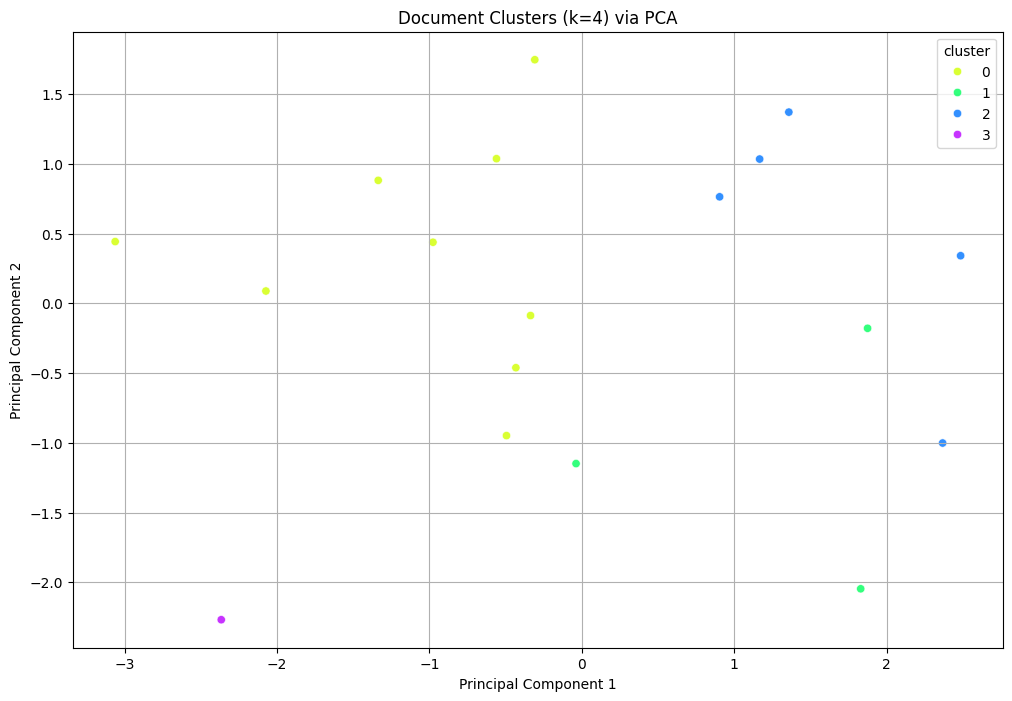

Displaying the first few rows of the DataFrame with assigned clusters and PCA components:


,pipeline_metaphor_density,avg_sentence_length,sentence_length_variance,function_word_ratio,unique_vocabulary_ratio,document_name,hierarchical_cluster,cluster,pca_one,pca_two
0,0.007959,21.724299,98.463538,0.368466,0.430200,ABSTRACT,3,3,-2.365740,-2.268564
1,0.115457,29.609302,299.893371,0.511781,0.322809,APHORISM,2,1,1.874560,-0.179118
2,0.057756,21.800000,269.978082,0.478524,0.397832,BIO,2,0,-0.432871,-0.461675
3,0.082093,36.138095,494.626771,0.444854,0.364080,BREVIEW,2,1,1.829415,-2.046803
4,0.040272,27.119816,299.244837,0.547154,0.274766,FABLE,0,2,1.357935,1.370741


In [89]:
# Visualize the clusters after reducing dimensions with PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

df_document_stylistics['pca_one'] = pca_features[:, 0]
df_document_stylistics['pca_two'] = pca_features[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='pca_one',
    y='pca_two',
    hue='cluster',
    palette=sns.color_palette('hsv', optimal_k),
    data=df_document_stylistics,
    legend='full',
    alpha=0.8
)
plt.title(f'Document Clusters (k={optimal_k}) via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

print("Displaying the first few rows of the DataFrame with assigned clusters and PCA components:")
display(df_document_stylistics.head())


In [82]:
# hierarchical clustering, display genres
from sklearn.cluster import AgglomerativeClustering


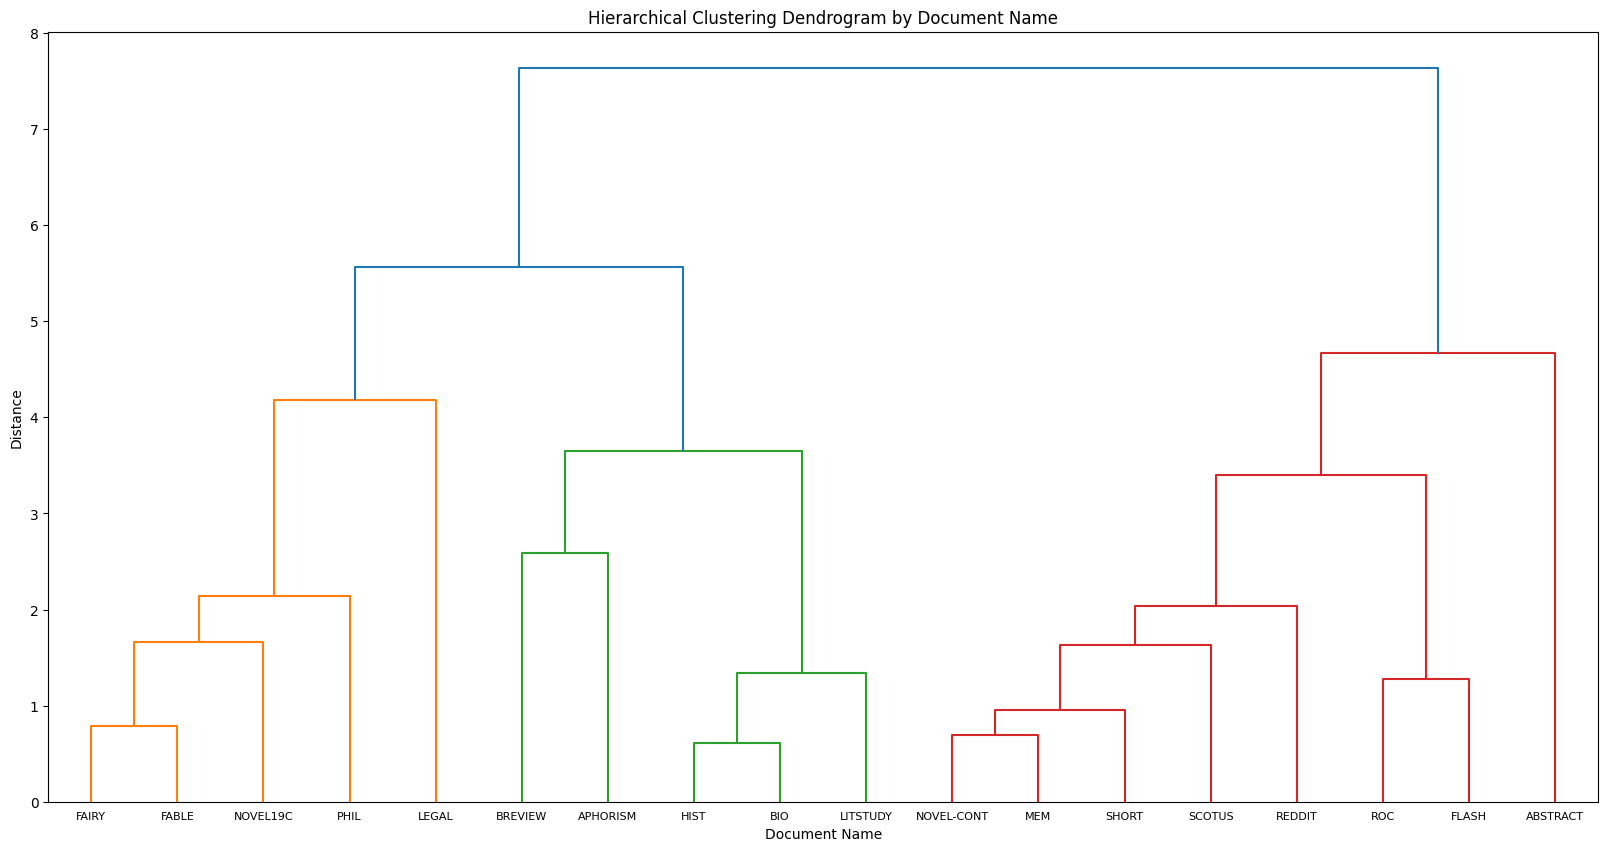

Please examine the dendrogram above to decide on the number of clusters (by drawing a horizontal line across). I will proceed with 3 clusters as an example.


In [83]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Use document_name from df_document_stylistics as labels
dendrogram_labels = df_document_stylistics['document_name'].tolist()

# Compute the linkage matrix
linked = linkage(scaled_features, method='ward') # 'ward' minimizes variance within clusters

# Plot the dendrogram
plt.figure(figsize=(20, 10)) # Increased figure size for better readability
dendrogram(linked,
           orientation='top',
           labels=dendrogram_labels, # Use document names as labels
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_font_size=8) # Adjusted font size for readability
plt.title('Hierarchical Clustering Dendrogram by Document Name')
plt.xlabel('Document Name')
plt.ylabel('Distance')
plt.show()

print("Please examine the dendrogram above to decide on the number of clusters (by drawing a horizontal line across). I will proceed with 3 clusters as an example.")

In [84]:
# Based on the dendrogram, choose the number of clusters
# For this example, let's target 3 clusters. You can adjust this 'n_clusters' value.
num_clusters_hac = 4

hierarchical_clusterer = AgglomerativeClustering(n_clusters=num_clusters_hac, linkage='ward')
hierarchical_clusters = hierarchical_clusterer.fit_predict(scaled_features)

df_document_stylistics['hierarchical_cluster'] = hierarchical_clusters

print(f"Document clustering with Agglomerative Clustering (n_clusters={num_clusters_hac}) complete.")
print("Hierarchical Cluster distribution:")
print(df_document_stylistics['hierarchical_cluster'].value_counts())

Document clustering with Agglomerative Clustering (n_clusters=4) complete.
Hierarchical Cluster distribution:
hierarchical_cluster
1    7
2    5
0    5
3    1
Name: count, dtype: int64


In [90]:
print("\nMean stylistic features per hierarchical cluster:")
cluster_means_hierarchical = df_document_stylistics.groupby('hierarchical_cluster').mean(numeric_only=True)
display(cluster_means_hierarchical.drop(columns=['pca_one', 'pca_two', 'cluster']))

print("\nDocuments within each hierarchical cluster:")
for cluster_id in sorted(df_document_stylistics['hierarchical_cluster'].unique()):
    docs_in_cluster = df_document_stylistics[df_document_stylistics['hierarchical_cluster'] == cluster_id]['document_name'].tolist()
    print(f"Cluster {cluster_id}: {docs_in_cluster}")



Mean stylistic features per hierarchical cluster:


,pipeline_metaphor_density,avg_sentence_length,sentence_length_variance,function_word_ratio,unique_vocabulary_ratio
hierarchical_cluster,,,,,
0,0.046311,26.526792,507.272470,0.516698,0.293855
1,0.040270,15.135088,151.383351,0.499377,0.378082
2,0.077894,27.505388,308.866737,0.470903,0.377452
3,0.007959,21.724299,98.463538,0.368466,0.430200



Documents within each hierarchical cluster:
Cluster 0: ['FABLE', 'FAIRY', 'LEGAL', 'NOVEL19C', 'PHIL']
Cluster 1: ['FLASH', 'MEM', 'NOVEL-CONT', 'REDDIT', 'ROC', 'SCOTUS', 'SHORT']
Cluster 2: ['APHORISM', 'BIO', 'BREVIEW', 'HIST', 'LITSTUDY']
Cluster 3: ['ABSTRACT']


# Qualitative analysis

In [92]:
import random

# Assuming test_results dictionary contains document_name as keys and list of metaphors as values
# We need to link these back to individual sentences in test_df

# Flatten test_df to iterate over sentences with their document names
sentences_with_doc_name = []
for _, row in test_df.iterrows():
    sentences_with_doc_name.append({
        'document_name': row['document_name'],
        'sentence': ' '.join(row['words']), # Reconstruct the sentence from words
        'original_index': _ # Keep track of original index if needed
    })

# Filter for sentences where metaphors were identified in their document
sentences_with_metaphors = []
for item in sentences_with_doc_name:
    doc_name = item['document_name']
    if doc_name in test_results and test_results[doc_name]:
        # For simplicity, we'll just check if the document had *any* metaphors
        # A more complex approach would involve re-running token_pipe on individual sentences
        # for precise per-sentence token identification.
        sentences_with_metaphors.append(item)


if sentences_with_metaphors:
    print("--- Sample Sentences with Identified Metaphors ---")
    # Randomly sample up to 5 sentences from those where metaphors were identified
    samples = random.sample(sentences_with_metaphors, min(5, len(sentences_with_metaphors)))

    for i, sample in enumerate(samples):
        doc_name = sample['document_name']
        sentence = sample['sentence']

        # Re-run token pipeline for exact token prediction on this specific sentence
        # This ensures we only get tokens that were predicted metaphorical *in this sentence*
        # and not just any metaphor found in the document.
        if sentence.strip(): # Avoid processing empty sentences
            try:
                token_preds = token_pipe(sentence)
                identified_metaphors = [e['word'].replace('▁', '').strip() for e in token_preds if e['entity_group'] == 'LABEL_1']
            except Exception as e:
                identified_metaphors = []
                print(f"Warning: Could not process sentence '{sentence[:50]}...' for token classification: {e}")
        else:
            identified_metaphors = []

        print(f"\nExample {i+1} (Document: {doc_name}):")
        print(f"  Sentence: {sentence}")
        print(f"  Identified Metaphors: {identified_metaphors}")
else:
    print("No sentences with identified metaphors found in the processed test_df.")

--- Sample Sentences with Identified Metaphors ---

Example 1 (Document: PHIL):
  Sentence: Up thither is the way to Zarathustra's cave it is not far wilt thou not attend to thy wounds at my home
  Identified Metaphors: ['Up']

Example 2 (Document: BREVIEW):
  Sentence: The result is a powerful collection that showcases Dumont s mastery of language narrative and imagery The plain language in The Pemmican Eaters is deceptive as many of the poems are more complex than they appear and warrant more than one reading
  Identified Metaphors: ['showcases', 'plain']

Example 3 (Document: PHIL):
  Sentence: Not by reason of any of them he said
  Identified Metaphors: []

Example 4 (Document: BIO):
  Sentence: I am also grateful that Julian Fellowes was inspired to write a series Downton Abbey based around Highclere Castle which Carnival Films produced and Peter Fincham ITV Chief Executive took the bold decision to back
  Identified Metaphors: ['around', 'took', 'bold']

Example 5 (Document: FAIR